## **MLP con Keras su MNIST (Jupyter)**

In [3]:
## Cell 1

import keras
from keras import layers
import numpy as np

print(keras.__version__)

2.15.0


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("Esempio lable:", y_train[:5])

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
Esempio lable: [5 0 4 1 9]


---

`load_data()` restituisce due tuple. Non stai calcolando nulla — stai solo caricando dati già preparati da Keras.

**x_train** — gli input. 60.000 immagini di cifre scritte a mano, ognuna da 28x28 pixel. Ogni pixel è un intero da 0 a 255 che rappresenta l'intensità del grigio. 0 = nero, 255 = bianco.

**y_train** — le label corrispondenti. 60.000 interi da 0 a 9. y_train[0] ti dice qual è la cifra nell'immagine x_train[0].

**x_test / y_test** — stesso formato, ma sono 10.000 immagini separate, mai viste durante il training. Servono esclusivamente per valutare il modello alla fine.

---

La separazione train/test è fondamentale: il modello viene addestrato solo su x_train, e valutato solo su x_test. Se valutassi sugli stessi dati di training, non sapresti mai se il modello generalizza o ha solo memorizzato.

---

Le tre dimensioni di x_train (60000, 28, 28):

60000 — numero di immagini
28 — righe di pixel
28 — colonne di pixel

---



In [6]:
# Riempi tu questa cell.
# Due operazioni:
# 1. Reshape: da (60000, 28, 28) a (60000, 784)
# 2. Normalizzazione: valori da [0, 255] a [0.0, 1.0]

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 784)
x_test shape: (10000, 784)


---

Due operazioni obbligatorie prima di passare i dati alla rete:

**Reshape** — un Dense layer si aspetta vettori 1D. Ogni immagine era una matrice 28x28. L'abbiamo appiattita in un vettore da 784 valori (28 × 28 = 784).

```
(60.000, 28, 28)  →  (60.000, 784)
```

**Normalizzazione** — i pixel avevano valori da 0 a 255. Dividendo per 255.0 li abbiamo portati nel range `[0.0, 1.0]`. Serve per mantenere i valori di input sulla stessa scala dei pesi della rete, evitando instabilità numerica durante il training.

---

In [7]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu", input_shape=(784,), name="layer1"),
        layers.Dense(64, activation="relu", name="layer2"),
        layers.Dense(10, activation="softmax", name="layer3"),
    ]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              (None, 128)               100480    
                                                                 
 layer2 (Dense)              (None, 64)                8256      
                                                                 
 layer3 (Dense)              (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


---

## Cosa abbiamo costruito

Sequential significa stack lineare di layer — i dati entrano dal primo e escono dall'ultimo, in sequenza, senza diramazioni.

Tre Dense layer significa tre trasformazioni lineari + attivazione, una dopo l'altra:

```
Input (784)  →  layer1 (128, ReLU)  →  layer2 (64, ReLU)  →  layer3 (10, Softmax)
```

Ogni Dense layer fa esattamente questo: `z = Wx + b` poi `a = f(z)`. La rete impara i valori di W e b durante il training.

---

## Leggi il Summary

Il summary ti dice una cosa fondamentale — quanti parametri ha ogni layer:

**layer1**: 784 input × 128 neuroni = 100.352 pesi + 128 bias = **100.480 parametri**

**layer2**: 128 input × 64 neuroni = 8.192 pesi + 64 bias = **8.256 parametri**

**layer3**: 64 input × 10 neuroni = 640 pesi + 10 bias = **650 parametri**

**Totale: 109.386 parametri** — tutti addestrabili. Sono i numeri che il Gradient Descent aggiornerà ad ogni passo di training.

---

Ogni layer Dense esegue questa operazione:

```
z = W · x + b
a = f(z)
```

Applicato al nostro caso concreto:

```
layer1:
- x = vettore input di 784 valori
- W = matrice di pesi (784 × 128)
- b = vettore bias (128 valori)
- z = W · x + b  →  vettore da 128 valori
- a = ReLU(z)    →  vettore da 128 valori (output del layer)

layer2:
- x = output del layer1, vettore da 128 valori
- W = matrice di pesi (128 × 64)
- b = vettore bias (64 valori)
- z = W · x + b  →  vettore da 64 valori
- a = ReLU(z)    →  vettore da 64 valori

layer3:
- x = output del layer2, vettore da 64 valori
- W = matrice di pesi (64 × 10)
- b = vettore bias (10 valori)
- z = W · x + b  →  vettore da 10 valori
- a = Softmax(z) →  vettore da 10 probabilità (sommano a 1)
```

Il conto dei parametri viene proprio da lì:

```
layer1: (784 × 128) + 128 = 100.352 + 128 = 100.480
layer2: (128 × 64)  + 64  =   8.192 + 64  =   8.256
layer3: (64  × 10)  + 10  =     640 + 10  =     650
```

Il `+ bias` in ogni layer è quella `b` nella formula — un valore aggiuntivo per ogni neurone che permette alla rete di shiftare l'attivazione. Senza bias la rete sarebbe molto meno espressiva.

---

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**optimizer** — l'algoritmo che aggiorna i pesi dopo ogni backpropagation. Abbiamo visto nella sezione 4.4 dei tuoi appunti che Adam è il default nella pratica perché combina Momentum e learning rate adattivo.

**loss** — la funzione che misura quanto la predizione è lontana dalla label reale. È il numero che il training cerca di minimizzare. Hai 10 classi e le label sono interi (0-9) — hai già risposto correttamente a questa domanda prima.

**metrics** — cosa vuoi monitorare durante il training, ma che non influenza l'aggiornamento dei pesi. È solo osservazione. Nel nostro caso vogliamo vedere la percentuale di predizioni corrette ad ogni epoch.

---


In [9]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=.2
)

Epoch 1/10


1500/1500 [==============================] - 7s 4ms/step - loss: 0.9114 - accuracy: 0.7203 - val_loss: 0.4540 - val_accuracy: 0.8746
Epoch 2/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.4212 - accuracy: 0.8790 - val_loss: 0.3579 - val_accuracy: 0.8935
Epoch 3/10
1500/1500 [==============================] - 5s 4ms/step - loss: 0.3572 - accuracy: 0.8971 - val_loss: 0.3113 - val_accuracy: 0.9106
Epoch 4/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3163 - accuracy: 0.9081 - val_loss: 0.2865 - val_accuracy: 0.9162
Epoch 5/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2847 - accuracy: 0.9172 - val_loss: 0.2570 - val_accuracy: 0.9250
Epoch 6/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2552 - accuracy: 0.9252 - val_loss: 0.2342 - val_accuracy: 0.9329
Epoch 7/10
1500/1500 [==============================] - 5s 3ms/step - loss: 0.2288 - accuracy: 0.9333 - val_loss: 0.2175 - val_accurac

---

`model.fit()` è il comando che avvia il training loop. Sotto il cofano Keras esegue questo ciclo per ogni epoch:

```
Per ogni epoch (10 volte):
  │
  ├── Prende x_train a blocchi da 32 campioni (mini-batch)
  │
  ├── Per ogni mini-batch:
  │     ├── Forward pass  → calcola la predizione
  │     ├── Loss          → misura l'errore
  │     ├── Backward pass → calcola i gradienti
  │     └── Adam          → aggiorna i pesi
  │
  └── Alla fine dell'epoch:
        ├── Misura loss e accuracy sul training set
        └── Misura loss e accuracy sul validation set (20%)
```

---

**I parametri che passiamo:**

`x_train, y_train` — i dati su cui il modello impara.

`batch_size=32` — Mini-batch GD. Ad ogni passo aggiorna i pesi su 32 campioni. Con 48.000 campioni di training (80% di 60.000) → 1.500 aggiornamenti per epoch.

`epochs=10` — il modello vede l'intero training set 10 volte.

`validation_split=0.2` — Keras riserva il 20% di x_train come validation set. Quei dati non vengono mai usati per aggiornare i pesi — servono solo per monitorare se il modello sta generalizzando o sta andando in overfitting.

---

```
loss          → deve scendere  (l'errore si riduce)
accuracy      → deve salire    (predice meglio)

val_loss      → deve scendere  (generalizza meglio)
val_accuracy  → deve salire    (generalizza meglio)
```

Il segnale di salute del training è il rapporto tra le due coppie:

```
SANO:
train loss scende  + val loss scende    → il modello impara e generalizza

OVERFITTING:
train loss scende  + val loss sale      → memorizza, non generalizza

UNDERFITTING:
train loss alta    + val loss alta      → il modello non impara
```

Nel tuo caso:

```
Epoch 10:
loss:     0.1715  ↓
val_loss: 0.1708  ↓  (quasi identica → nessun overfitting)
```

---

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 [==============================] - 1s 2ms/step - loss: 0.1704 - accuracy: 0.9505
Test Loss: 0.1704
Test Accuracy: 0.9505


Il modello classifica correttamente il 95% delle cifre su dati mai visti durante il training.

```
Training accuracy:   94.87%  (dati visti)
Validation accuracy: 95.13%  (subset di training, non visti)
Test accuracy:       95.05%  (dati completamente nuovi)
```

Le tre cifre sono allineate — nessun overfitting, il modello generalizza bene.

---


In [11]:
import matplotlib.pyplot as plt


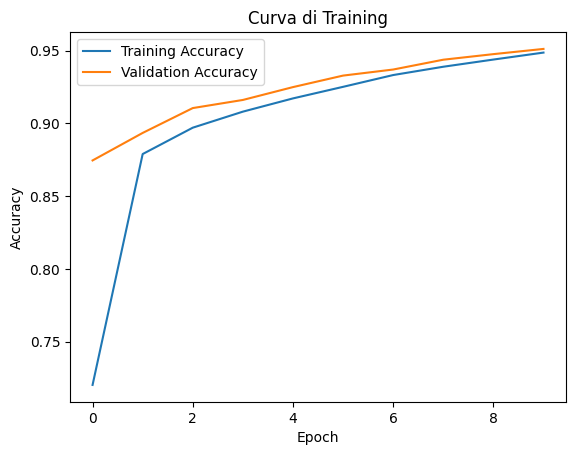

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Curva di Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

---

```
Epoch 1:  gap ampio  → il modello sta ancora imparando
Epoch 10: gap minimo → le due curve convergono
```

Quando le due curve convergono e salgono insieme significa che il modello sta imparando pattern reali, non rumore. Se vedessi la val_accuracy appiattirsi o scendere mentre la training accuracy continua a salire, quello sarebbe il segnale visivo di overfitting.

---

## Recap completo dell'esercizio

```
[Cell 1] Import librerie
[Cell 2] Carica MNIST         → x_train (60000, 28, 28), y_train (60000,)
[Cell 3] Preprocessing        → reshape (60000, 784) + normalizzazione /255.0
[Cell 4] Costruisci modello   → Sequential, 3 Dense layer
[Cell 5] Compile              → Adam, sparse_categorical_crossentropy, accuracy
[Cell 6] Training             → 10 epoch, batch_size=32, validation_split=0.2
[Cell 7] Evaluate             → Test accuracy 95.05%
[Cell 8] Plot                 → training e val accuracy convergono
```

Hai costruito, addestrato e valutato il tuo primo MLP in Keras da zero.

---
